In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Flatten, Dense, UpSampling2D, Dropout
)
from tensorflow.keras.models import Model, Sequential
import numpy as np
import matplotlib.pyplot as plt
import time

In [5]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images: ", X_train.shape)
print("Testing Images: ", X_test.shape)
print("Training Labels: ", y_train.shape)
print("Testing Labels: ", y_test.shape)

Training Images:  (50000, 32, 32, 3)
Testing Images:  (10000, 32, 32, 3)
Training Labels:  (50000, 1)
Testing Labels:  (10000, 1)


In [6]:
# Normalize the pixel values to the range [0, 1]
X_train = X_train.astype('float32')/255.0
X_test = X_test.astype('float32')/255.0

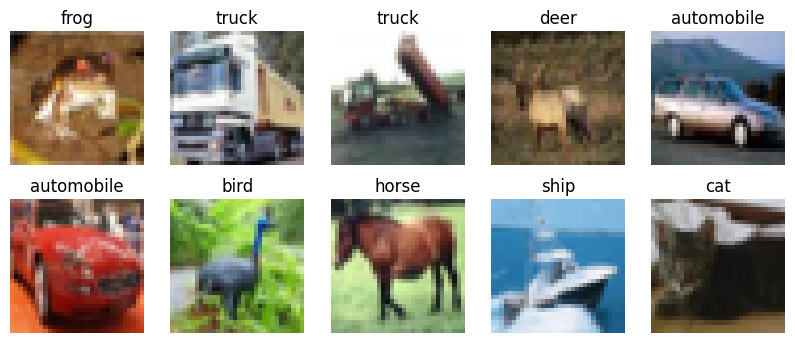

In [7]:
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

In [8]:
def build_autoencoder(filter_size=3, pool_size=2, filters=[32,64], input_shape=(32,32,3)):
    input_img = Input(shape=input_shape)

    # Encoder
    x = input_img

    for f in filters:
        X = Conv2D(
            f, (filter_size, filter_size),
            activation='relu',
            padding='same'
        )(x)

        x = MaxPooling2D(
            (pool_size, pool_size),
            padding='same'
        )(x)

    encoded = x

    for f in reversed(filters):
        x = Conv2D(
            f,
            (filter_size, filter_size),
            activation='relu',
            padding='same'
        )(x)

        x = UpSampling2D(
            (pool_size, pool_size)
        )(x)

    decoded = Conv2D(
        3,
        (3, 3),
        activation='sigmoid',
        padding='same'
    )(x)

    autoencoder = Model(input_img, decoded)
    encoder = Model(input_img, encoded)

    return autoencoder, encoder

In [9]:
filter_sizes = [3,5]
pool_sizes = [2]
filter_configs = [
    [16, 32],
    [32, 64],
    [32,64,128]
]
epochs_list = [10]

best_loss = float("inf")
best_config = None
best_autoencoder = None
best_encoder = None

results = []

In [10]:
for f_size in filter_sizes:
    for p_size in pool_sizes:
        for filters in filter_configs:
            for epochs in epochs_list:

                print(f"\nTraining config:")
                print(f"Filter Size: {f_size}")
                print(f"Pool Size: {p_size}")
                print(f"Filters: {filters}")
                print(f"Epochs: {epochs}")

                autoencoder, encoder = build_autoencoder(
                    filter_size = f_size,
                    pool_size=p_size,
                    filters=filters
                )

                autoencoder.compile(
                    optimizer='adam',
                    loss='mse'
                )

                history = autoencoder.fit(
                    X_train,
                    X_train,
                    epochs=epochs,
                    batch_size=128,
                    validation_split=0.1,
                    verbose=1
                )

                val_loss = min(history.history['val_loss'])

                results.append({
                    "filter_size": f_size,
                    "pool_size": p_size,
                    "filters": filters,
                    "epochs": epochs,
                    "val_loss": val_loss
                })

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_config = {
                        "filter_size": f_size,
                        "pool_size": p_size,
                        "filters": filters,
                        "epochs": epochs
                    }
                    best_autoencoder = autoencoder
                    best_encoder=encoder


Training config:
Filter Size: 3
Pool Size: 2
Filters: [16, 32]
Epochs: 10


2026-05-27 12:54:31.099729: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4
2026-05-27 12:54:31.099754: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-05-27 12:54:31.099765: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-05-27 12:54:31.099783: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-27 12:54:31.099800: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Epoch 1/10


2026-05-27 12:54:32.295671: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


352/352 ━━━━━━━━━━━━━━━━━━━━ 98s 276ms/step - loss: 0.0241 - val_loss: 0.0169
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - loss: 0.0164 - val_loss: 0.0159
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - loss: 0.0155 - val_loss: 0.0151
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - loss: 0.0152 - val_loss: 0.0150
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 276ms/step - loss: 0.0149 - val_loss: 0.0146
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 97s 275ms/step - loss: 0.0147 - val_loss: 0.0144
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 98s 279ms/step - loss: 0.0145 - val_loss: 0.0142
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 98s 277ms/step - loss: 0.0144 - val_loss: 0.0144
Epoch 9/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 100s 284ms/step - loss: 0.0143 - val_loss: 0.0142
Epoch 10/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 101s 287ms/step - loss: 0.0142 - val_loss: 0.0139

Training config:
Filter Size: 3
Pool Size: 2
Filters: [32, 64]
Epochs: 10
Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 121

In [11]:
print("\nBest Configuration:")
print(best_config)
print("Best Validation Loss: ", best_loss)


Best Configuration:
{'filter_size': 3, 'pool_size': 2, 'filters': [32, 64], 'epochs': 10}
Best Validation Loss:  0.013419381342828274


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


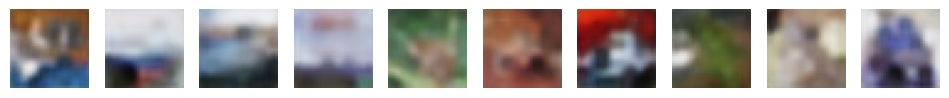

In [16]:
reconstructed = best_autoencoder.predict(X_test[:10])

plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(X_test[i])
    plt.axis("off")

    plt.subplot(2,10,i+1)
    plt.imshow(reconstructed[i])
    plt.axis("off")

plt.show()


In [17]:
compressed_train = best_encoder.predict(X_train)
compressed_test = best_encoder.predict(X_test)

print("Compressed train shape: ", compressed_train.shape)
print("Compressed test shape: ", compressed_test.shape)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 983us/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Compressed train shape:  (50000, 8, 8, 3)
Compressed test shape:  (10000, 8, 8, 3)


#Baseline_CNN_Classifier

In [19]:
def build_baseline_cnn():
    model=Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [21]:
baseline_model = build_baseline_cnn()

start = time.time()

baseline_history = baseline_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

baseline_time = time.time() - start

Epoch 1/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.3181 - loss: 1.8664 - val_accuracy: 0.4950 - val_loss: 1.4097
Epoch 2/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4512 - loss: 1.5194 - val_accuracy: 0.5630 - val_loss: 1.2577
Epoch 3/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5148 - loss: 1.3570 - val_accuracy: 0.5848 - val_loss: 1.1841
Epoch 4/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5480 - loss: 1.2824 - val_accuracy: 0.6072 - val_loss: 1.1249
Epoch 5/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5711 - loss: 1.2282 - val_accuracy: 0.6192 - val_loss: 1.1016
Epoch 6/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.5856 - loss: 1.1987 - val_accuracy: 0.6322 - val_loss: 1.0561
Epoch 7/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.5940 - loss: 1.1722 - val_accuracy: 0.6496 - val_loss: 1.0227
Epoch 8/10
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.6007 - loss: 1.1546 - val_accu

In [23]:
baseline_loss, baseline_acc = baseline_model.evaluate(X_test, y_test)

print("Baseline Accuracy: ", baseline_acc)
print("Baseline Training Time", baseline_time)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6419 - loss: 1.0329
Baseline Accuracy:  0.6419000029563904
Baseline Training Time 71.17495608329773


#Compressed_CNN_Classifier

In [26]:
def build_compressed_cnn(input_shape):
    model=Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2,2)),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.5),

        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [28]:
compressed_model = build_compressed_cnn(compressed_train.shape[1:])

start = time.time()

compresed_history = compressed_model.fit(
    compressed_train,
    y_train,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

compressed_time = time.time() - start

/Volumes/Vivek_SSD/All Models/DLenv311/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2550 - loss: 2.0265 - val_accuracy: 0.3644 - val_loss: 1.7880


In [29]:
compressed_loss, compressed_acc = compressed_model.evaluate(
    compressed_test,
    y_test
)

print("Compressed Accuracy: ", compressed_acc)
print("Compressed Training Time: ", compressed_time)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3844 - loss: 1.7768
Compressed Accuracy:  0.38440001010894775
Compressed Training Time:  3.480813980102539


In [31]:
print("\nFINAL COMPARISON")
print(f"Baseline CNN Accuracy: {baseline_acc:.4f}")
print(f"Compressed CNN Accuracy: {compressed_acc:.4f}")
print(f"Baseline Training Time: {baseline_time:.2f} sec")
print(f"Compressed Training Time: {compressed_time:.2f} sec")


FINAL COMPARISON
Baseline CNN Accuracy: 0.6419
Compressed CNN Accuracy: 0.3844
Baseline Training Time: 71.17 sec
Compressed Training Time: 3.48 sec


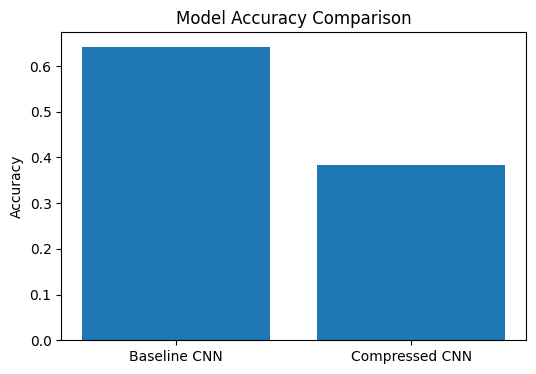

In [32]:
models = ['Baseline CNN', 'Compressed CNN']
accuracies = [baseline_acc, compressed_acc]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.show()